# EDA - Observation


In [2]:
import numpy as np
import pandas as pd

import re as re

import seaborn as sn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [3]:
pd.set_option('display.max_columns', None)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [4]:
df = pd.read_csv("train.csv", low_memory=False)
df[:3]

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good


In [5]:
df.shape

(100000, 28)

In [6]:
df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

Bao gồm các 27 features + 1 cột STT và 100000 rows

In [7]:
# Các cột Numerical hiện tại
df.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


In [8]:
# Các cột Categorical hiện tại
df.describe(exclude=np.number)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Num_of_Loan,Type_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000,100000,100000,90015,100000,100000,100000,100000,100000,88592,92998,100000,100000,100000,90970,100000,95521,100000,98800,100000
unique,100000,12500,8,10139,1788,12501,16,18940,434,6260,749,4384,4,13178,404,3,91049,7,98792,3
top,0x1602,CUS_0xd40,January,Langep,38,#F%$D@*&8,_______,36585.12,3,Not Specified,19,_,Standard,1360.45,15 Years and 11 Months,Yes,__10000__,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
freq,1,8,12500,44,2833,5572,7062,16,14386,1408,5327,2091,36479,24,446,52326,4305,25513,9,53174


Outliers ở nhiều cột, bao gồm cả các cột numerical và categorical

Kiểm tra datatype của các feature

In [9]:
object_col = df.describe(include='O').columns
object_col

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Num_of_Loan', 'Type_of_Loan',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_History_Age', 'Payment_of_Min_Amount',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

Có rất nhiều cột bị xếp sai datatype, điều này sẽ ảnh hưởng quá trình vẽ đồ thị trước khi cleaning

In [11]:
# Kiểm tra missing values
df.isnull().sum()

ID                              0
Customer_ID                     0
Month                           0
Name                         9985
Age                             0
SSN                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment       7002
Changed_Credit_Limit            0
Num_Credit_Inquiries         1965
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age           9030
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      4479
Payment_Behaviour               0
Monthly_Balance              1200
Credit_Score                    0
dtype: int64

<Figure size 1000x600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Missing Data Map')

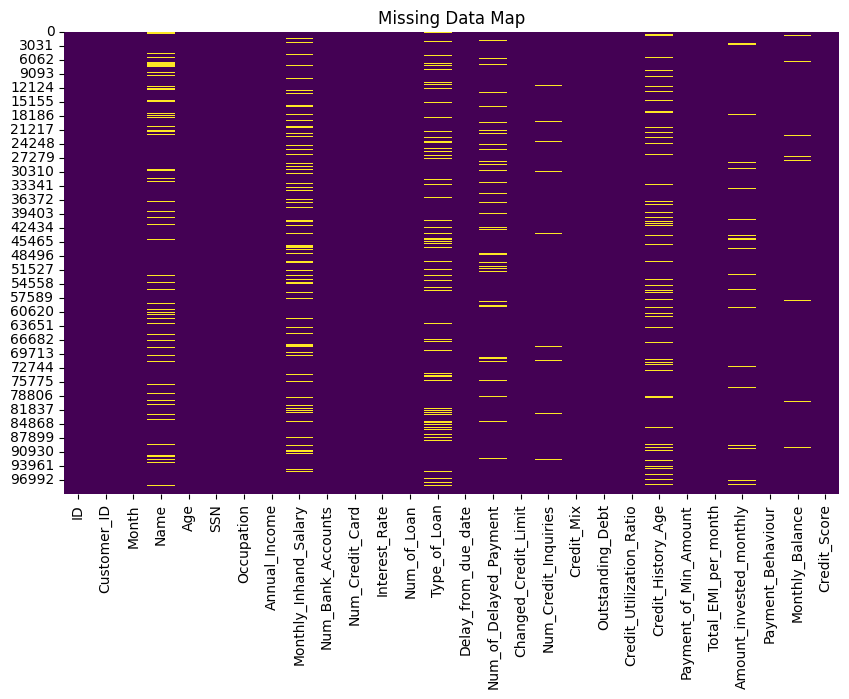

In [12]:
# Check missing values with heatmaps
plt.figure(figsize=(10,6))
sn.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Map")
plt.show()

In [13]:
# Kiểm tra outlier ở cột Month
df["Month"].unique() # Each customer has data from Jan-Aug

array(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August'], dtype=object)

- Features with recurrance data but there are those change monthly
- For features with recurrance data, sometimes some features has inconsistent data
- How to differentiate those 2 types of features?
- Planned solution: 8 months so if the inconsistent change more than 1 or 2

### Xử lý datatypes trước khi quan sát

In [14]:
df[df["Customer_ID"] == "CUS_0x2dbc"] 
# The Credit_History_Age of each customer not interrupt with nan

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
16,0x161a,CUS_0x2dbc,January,Langep,34,486-85-3974,_______,143162.64,12187.22,1,5,8,3,"Auto Loan, Auto Loan, and Not Specified",5,8,7.1,3.0,Good,1303.01,28.616735,17 Years and 9 Months,No,246.992319,168.413702679309,!@9#%8,1043.3159778669492,Good
17,0x161b,CUS_0x2dbc,February,NaN,34,486-85-3974,Engineer,143162.64,12187.22,1,5,8,3,"Auto Loan, Auto Loan, and Not Specified",13,6,7.1,3.0,Good,1303.01,41.702573,17 Years and 10 Months,No,246.992319,232.86038375993544,High_spent_Small_value_payments,998.8692967863226,Good
18,0x161c,CUS_0x2dbc,March,Langep,34,486-85-3974,_______,143162.64,NaN,1,5,8,3,"Auto Loan, Auto Loan, and Not Specified",8,7,11.1,NaN,Good,1303.01,26.519815,17 Years and 11 Months,No,246.992319,__10000__,High_spent_Small_value_payments,715.741367403555,Good
19,0x161d,CUS_0x2dbc,April,Langep,34,486-85-3974,Engineer,143162.64,12187.22,1,5,8,3,"Auto Loan, Auto Loan, and Not Specified",8,5,9.1,3.0,_,1303.01,39.501648,NaN,No,246.992319,825.2162699393922,Low_spent_Medium_value_payments,426.5134106068658,Good
20,0x161e,CUS_0x2dbc,May,Langep,34,486-85-3974,_______,143162.64,12187.22,1,5,8,3,"Auto Loan, Auto Loan, and Not Specified",10,5,7.1,3.0,Good,1303.01,31.376150,18 Years and 1 Months,No,246.992319,430.9475278803298,Low_spent_Large_value_payments,810.7821526659284,Good
21,0x161f,CUS_0x2dbc,June,Langep,34,486-85-3974,Engineer,143162.64,12187.22,1,5,8,967,"Auto Loan, Auto Loan, and Not Specified",8,6,7.1,3.0,Good,1303.01,39.783993,18 Years and 2 Months,No,246.992319,257.80809942568976,High_spent_Medium_value_payments,963.9215811205684,Good
22,0x1620,CUS_0x2dbc,July,NaN,34,486-85-3974,Engineer,143162.64,12187.22,1,5,8,3,"Auto Loan, Auto Loan, and Not Specified",8,6,7.1,3.0,Good,1303.01,38.068624,18 Years and 3 Months,No,246.992319,263.17416316163934,High_spent_Small_value_payments,968.5555173846187,Standard
23,0x1621,CUS_0x2dbc,August,Langep,34,486-85-3974,Engineer,143162.64,12187.22,1,5,8,3,"Auto Loan, Auto Loan, and Not Specified",8,6,7.1,3.0,Good,1303.01,38.374753,18 Years and 4 Months,No,246.992319,__10000__,High_spent_Small_value_payments,895.494583180492,Standard


In [15]:
df[df['Num_Bank_Accounts'] == -1].iloc[:16]
# -1 is not only outliner but there are customers with negative number of bank account
# CUS_0xa878, CUS_0x4f2a
df[df['Customer_ID'] == "CUS_0x4f2a"] 
# Seems like for customer with 0 Bank Account can get negative when their credit cards decrease
# -> Fix these -1 to 0

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
30330,0xc7b8,CUS_0x4f2a,March,Margaretf,39,807-03-5415,Engineer,128305.76,10434.146667,-1,6,1,2_,"Auto Loan, and Not Specified",5,3,9.49,6.0,Good,1151.7,40.586736,22 Years and 5 Months,No,196.587321,230.9223857499363,High_spent_Large_value_payments,855.9049597507532,Standard
30331,0xc7b9,CUS_0x4f2a,April,Margaretf,40,#F%$D@*&8,Engineer,128305.76,NaN,-1,6,1,2,"Auto Loan, and Not Specified",5,6,14.49,6.0,Good,1151.7_,39.369401,22 Years and 6 Months,No,196.587321,524.3044177743545,Low_spent_Large_value_payments,592.522927726335,Good
30332,0xc7ba,CUS_0x4f2a,May,Margaretf,40,807-03-5415,Engineer,128305.76,10434.146667,-1,6,1,2,"Auto Loan, and Not Specified",1,8,9.49,6.0,Good,1151.7,28.702053,22 Years and 7 Months,No,196.587321,150.0966753535676,High_spent_Large_value_payments,936.7306701471217,Good
30333,0xc7bb,CUS_0x4f2a,June,Margaretf,40,807-03-5415,Engineer,128305.76,10434.146667,-1,6,1,2,"Auto Loan, and Not Specified",5,6,9.49,6.0,Good,1151.7,34.808390,22 Years and 8 Months,No,196.587321,1006.6980690205388,Low_spent_Medium_value_payments,120.12927648015079,Good
30334,0xc7bc,CUS_0x4f2a,July,Margaretf,40,807-03-5415,Engineer,128305.76,10434.146667,-1,6,1,2,"Auto Loan, and Not Specified",9,3,9.49,6.0,Good,1151.7,35.206427,NaN,No,42850.000000,172.99202124673786,High_spent_Large_value_payments,913.8353242539515,Good
30335,0xc7bd,CUS_0x4f2a,August,Margaretf,40,807-03-5415,Engineer,22136920.0,NaN,-1,6,1,2,"Auto Loan, and Not Specified",10,6,9.49,6.0,_,1151.7,38.278518,22 Years and 10 Months,No,196.587321,338.67230317776176,High_spent_Medium_value_payments,758.1550423229277,Good
43689,0x115ff,CUS_0xa878,February,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.922500,-1,6,7,0,NaN,27,1,4.97,1.0,Good,607.78,37.286105,20 Years and 6 Months,No,0.000000,668.1444536762707,!@9#%8,588.9477963237292,Poor
43690,0x11600,CUS_0xa878,March,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.922500,-1,6,7,0,NaN,27,1,0.9699999999999998,1.0,Good,607.78,41.915627,20 Years and 7 Months,No,0.000000,142.31978881674561,High_spent_Large_value_payments,1084.7724611832548,Poor
43691,0x11601,CUS_0xa878,April,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.922500,-1,6,7,0,NaN,27,1,4.97,1.0,Good,607.78,41.799942,20 Years and 8 Months,No,0.000000,467.563922615828,High_spent_Small_value_payments,779.528327384172,Poor
43692,0x11602,CUS_0xa878,May,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.922500,-1,6,7,0,NaN,25,2,2.97,1.0,Good,607.78,46.244581,20 Years and 9 Months,No,0.000000,NaN,High_spent_Large_value_payments,1037.5063384360787,Poor


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
30328,0xc7b6,CUS_0x4f2a,January,Margaretf,39,807-03-5415,Engineer,128305.76,10434.146667,0,7,1,2,"Auto Loan, and Not Specified",5,6,9.49,2.0,Good,1151.7,28.555646,22 Years and 3 Months,No,196.587321,268.7720817598091,High_spent_Medium_value_payments,828.0552637408804,Standard
30329,0xc7b7,CUS_0x4f2a,February,Margaretf,39,807-03-5415,Engineer,128305.76,10434.146667,0,7,1,2_,"Auto Loan, and Not Specified",5,6,3.49,2.0,Good,1151.7,30.343064,22 Years and 4 Months,No,196.587321,588.7732847049177,Low_spent_Small_value_payments,548.0540607957716,Standard
30330,0xc7b8,CUS_0x4f2a,March,Margaretf,39,807-03-5415,Engineer,128305.76,10434.146667,-1,6,1,2_,"Auto Loan, and Not Specified",5,3,9.49,6.0,Good,1151.7,40.586736,22 Years and 5 Months,No,196.587321,230.9223857499363,High_spent_Large_value_payments,855.9049597507532,Standard
30331,0xc7b9,CUS_0x4f2a,April,Margaretf,40,#F%$D@*&8,Engineer,128305.76,NaN,-1,6,1,2,"Auto Loan, and Not Specified",5,6,14.49,6.0,Good,1151.7_,39.369401,22 Years and 6 Months,No,196.587321,524.3044177743545,Low_spent_Large_value_payments,592.522927726335,Good
30332,0xc7ba,CUS_0x4f2a,May,Margaretf,40,807-03-5415,Engineer,128305.76,10434.146667,-1,6,1,2,"Auto Loan, and Not Specified",1,8,9.49,6.0,Good,1151.7,28.702053,22 Years and 7 Months,No,196.587321,150.0966753535676,High_spent_Large_value_payments,936.7306701471217,Good
30333,0xc7bb,CUS_0x4f2a,June,Margaretf,40,807-03-5415,Engineer,128305.76,10434.146667,-1,6,1,2,"Auto Loan, and Not Specified",5,6,9.49,6.0,Good,1151.7,34.808390,22 Years and 8 Months,No,196.587321,1006.6980690205388,Low_spent_Medium_value_payments,120.12927648015079,Good
30334,0xc7bc,CUS_0x4f2a,July,Margaretf,40,807-03-5415,Engineer,128305.76,10434.146667,-1,6,1,2,"Auto Loan, and Not Specified",9,3,9.49,6.0,Good,1151.7,35.206427,NaN,No,42850.000000,172.99202124673786,High_spent_Large_value_payments,913.8353242539515,Good
30335,0xc7bd,CUS_0x4f2a,August,Margaretf,40,807-03-5415,Engineer,22136920.0,NaN,-1,6,1,2,"Auto Loan, and Not Specified",10,6,9.49,6.0,_,1151.7,38.278518,22 Years and 10 Months,No,196.587321,338.67230317776176,High_spent_Medium_value_payments,758.1550423229277,Good


In [16]:
df[df["Customer_ID"] == "CUS_0x7ce5"] 
# For few cases, Num_Bank_Accounts relates to Num_Credit_Card

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
4712,0x319e,CUS_0x7ce5,January,Singhj,23,#F%$D@*&8,_______,101912.13,8503.6775,5,1,4,0,NaN,5,3,4.83,2.0,Good,152.6_,29.454223,19 Years and 11 Months,NM,0.0,295.87664723347774,Low_spent_Medium_value_payments,834.4911027665222,Good
4713,0x319f,CUS_0x7ce5,February,Singhj,23,954-97-8593,Writer,101912.13,8503.6775,5,1,4,0,NaN,5,0,_,2.0,Good,152.6,42.143932,20 Years and 0 Months,No,0.0,349.3415713189695,Low_spent_Medium_value_payments,781.0261786810304,Good
4714,0x31a0,CUS_0x7ce5,March,Singhj,24,954-97-8593,Writer,101912.13,8503.6775,5,1,4,0,NaN,5,NaN,2.83,2.0,_,152.6,27.336863,20 Years and 1 Months,No,0.0,783.8010625520848,Low_spent_Large_value_payments,336.56668744791517,Good
4715,0x31a1,CUS_0x7ce5,April,Singhj,24,954-97-8593,Writer,101912.13,8503.6775,5,1,4,0,NaN,5,NaN,5.83,NaN,_,152.6,33.506761,20 Years and 2 Months,No,0.0,90.13946917553051,High_spent_Large_value_payments,1000.2282808244696,Good
4716,0x31a2,CUS_0x7ce5,May,Singhj,24,954-97-8593,Writer,101912.13,8503.6775,4,0,4,0,NaN,5,2,4.83,2.0,Good,152.6,36.707990,20 Years and 3 Months,No,0.0,346.9351161960141,Low_spent_Large_value_payments,773.4326338039859,Good
4717,0x31a3,CUS_0x7ce5,June,Singhj,24,954-97-8593,_______,101912.13_,8503.6775,4,0,4,0,NaN,5,6,4.83,2.0,Good,152.6,36.928316,20 Years and 4 Months,No,0.0,66.23205272972119,High_spent_Large_value_payments,1024.1356972702788,Standard
4718,0x31a4,CUS_0x7ce5,July,Singhj,24,954-97-8593,_______,101912.13,8503.6775,4,0,4,0,NaN,5,6,4.83,1351.0,Good,152.6,26.630283,20 Years and 5 Months,NM,0.0,287.4291681173733,Low_spent_Medium_value_payments,842.9385818826267,Good
4719,0x31a5,CUS_0x7ce5,August,Singhj,24,954-97-8593,Writer,101912.13,8503.6775,4,0,4,0,NaN,5,3,4.83,2.0,_,152.6,42.515861,20 Years and 6 Months,No,0.0,411.27366724738965,!@9#%8,719.0940827526103,Good


In [17]:
# Function to detect those got into wrong datatype
def detect_mixed_numeric_cols(df, sample_size=100, threshold=0.8, skip_cols=False):
    potential_numeric_cols = []
   
    for col in df.select_dtypes(include=['object']).columns:

        if col in skip_cols:
            continue
        
        unique_values = df[col].unique()
       
        if len(unique_values) == 0:
            continue
       
        if len(unique_values) > sample_size:
            sample = np.random.choice(unique_values, size=sample_size, replace=False)
        else:
            sample = unique_values
            
        numeric_like_count = 0
        for value in sample:
    
            if re.search(r'\d', str(value)):
                numeric_like_count += 1
        
        # Calculate the ratio of numeric-like values in the sample
        ratio = numeric_like_count / len(sample)
        
        # If the ratio exceeds the threshold, it's a potential numeric column
        if ratio >= threshold:
            potential_numeric_cols.append(col)
            
    return potential_numeric_cols

In [18]:
wrong_dtypes = detect_mixed_numeric_cols(df, skip_cols=["ID", "Customer_ID", "SSN", "Credit_History_Age"])

In [19]:
wrong_dtypes
df.select_dtypes(include=["object"]).columns

['Age',
 'Annual_Income',
 'Num_of_Loan',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Outstanding_Debt',
 'Amount_invested_monthly',
 'Monthly_Balance']

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Num_of_Loan', 'Type_of_Loan',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_History_Age', 'Payment_of_Min_Amount',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

Credit_History_Age

In [20]:
# Credit_History_Age
pattern = r"^\d+\s+Years?\s+and\s+\d+\s+Months?$"
mask = ~df['Credit_History_Age'].str.match(pattern).fillna(False)
df[mask]

# No outliners but missing values

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
7,0x1609,CUS_0xd40,August,NaN,23,#F%$D@*&8,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,6,11.27,4.0,Good,809.98,23.933795,NaN,No,49.574949,24.785216509052056,High_spent_Medium_value_payments,358.12416760938714,Standard
19,0x161d,CUS_0x2dbc,April,Langep,34,486-85-3974,Engineer,143162.64,12187.220000,1,5,8,3,"Auto Loan, Auto Loan, and Not Specified",8,5,9.1,3.0,_,1303.01,39.501648,NaN,No,246.992319,825.2162699393922,Low_spent_Medium_value_payments,426.5134106068658,Good
40,0x163e,CUS_0x95ee,January,Np,31,612-70-8987,Lawyer,73928.46,NaN,4,1288,8,0,NaN,12,10,10.14,2.0,Good,548.2,39.962685,NaN,No,15015.000000,98.67440994166124,High_spent_Large_value_payments,740.1960900583389,Good
42,0x1640,CUS_0x95ee,March,Np,31,612-70-8987,Lawyer,73928.46,5988.705000,4,5,8,0,NaN,8,7,10.14,2.0,Good,548.2,40.712187,NaN,No,0.000000,150.05973429800815,High_spent_Medium_value_payments,698.8107657019921,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99944,0x25f9e,CUS_0x51b3,January,Ryana,33,837-85-9800,Media_Manager,59146.36,NaN,2,5,6,1,Personal Loan,8,6,6.68,2.0,_,418.03,34.720661,NaN,No,26.778419,606.4365424304076,Low_spent_Small_value_payments,147.67137163088418,Standard
99963,0x25fb9,CUS_0x372c,April,Lucia Mutikanik,-500,340-85-7301,Lawyer,42903.79,NaN,0,4,6,1,Not Specified,14,0,5.1,1.0,Good,1079.48,30.625298,NaN,No,34.975457,31.19391926667726,High_spent_Large_value_payments,520.6622073726148,Standard
99968,0x25fc2,CUS_0xf16,January,Maria Sheahanb,44,#F%$D@*&8,Media_Manager,16680.35,1528.029167,1,1,5,4,"Payday Loan, Student Loan, Mortgage Loan, and ...",4,0,5.69,4.0,Good,897.16,39.868572,NaN,NM,41.113561,52.95197781627658,High_spent_Small_value_payments,318.73737826046414,Good
99975,0x25fc9,CUS_0xf16,August,Maria Sheahanb,45,868-70-2218,Media_Manager,16680.35,NaN,1,1,5,4,"Payday Loan, Student Loan, Mortgage Loan, and ...",1,0,5.69,8.0,Good,897.16,41.212367,NaN,No,41.113561,70.8055497847255,Low_spent_Large_value_payments,310.8838062920152,Good


Xử lý các feature numerical bị xếp sai vào nhóm categorical

In [21]:
# List các feature sẽ không cần xử lý tạm thời
skip_columns = ["ID", "Name", "Customer_ID", "SSN", "Credit_History_Age"]

In [22]:
# Functions to fix the datatypes above
def fix_mixed_numeric(df, columns, skip_cols=None):
   
    if skip_cols is None:
        skip_cols = []
    
    for col in columns:
        if col in skip_cols:
            continue
        
        cleaned = []
        for v in df[col]:
            if pd.isna(v):
                cleaned.append(pd.NA)
                continue
            
            v_str = str(v).strip()
            
            # Common missing tokens
            if v_str.lower() in ["nan", "null", "na", "n/a", "none", ""]:
                cleaned.append(pd.NA)
                continue
            
            # Extract digits + dot + minus
            numeric_part = re.sub(r"[^0-9\.\-]", "", v_str)
            
            # Count how much of original is symbols
            non_numeric_count = sum(1 for ch in v_str if not ch.isdigit() and ch not in ".-")
            
            if numeric_part == "" or non_numeric_count > 2:
                # Too corrupted → drop
                cleaned.append(pd.NA)
            else:
                cleaned.append(numeric_part)
        
        # Convert to numeric after cleaning
        df[col] = pd.to_numeric(cleaned, errors="coerce")
    
    return df

In [23]:
fix_mixed_numeric(df, wrong_dtypes, skip_cols=skip_columns)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7.0,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.415295,High_spent_Small_value_payments,312.494089,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.280222,Low_spent_Large_value_payments,284.629162,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7.0,NaN,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521,Low_spent_Medium_value_payments,331.209863,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4.0,6.27,4.0,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.458074,Low_spent_Small_value_payments,223.451310,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153,High_spent_Medium_value_payments,341.489231,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",23,7.0,11.50,3.0,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.971333,High_spent_Large_value_payments,479.866228,Poor
99996,0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",18,7.0,11.50,3.0,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.185950,High_spent_Medium_value_payments,496.651610,Poor
99997,0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,5729,2,"Auto Loan, and Student Loan",27,6.0,11.50,3.0,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.028477,High_spent_Large_value_payments,516.809083,Poor
99998,0x25fec,CUS_0x942c,July,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",20,NaN,11.50,3.0,Good,502.38,33.638208,31 Years and 9 Months,No,35.104023,251.672582,Low_spent_Large_value_payments,319.164979,Standard


Phân loại các nhóm numerical và categorical

In [24]:
# Categorize dataset

object_columns = df.select_dtypes(include=['object']).columns.tolist()
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

object_columns
numeric_columns

['ID',
 'Customer_ID',
 'Month',
 'Name',
 'SSN',
 'Occupation',
 'Type_of_Loan',
 'Credit_Mix',
 'Credit_History_Age',
 'Payment_of_Min_Amount',
 'Payment_Behaviour',
 'Credit_Score']

['Age',
 'Annual_Income',
 'Monthly_Inhand_Salary',
 'Num_Bank_Accounts',
 'Num_Credit_Card',
 'Interest_Rate',
 'Num_of_Loan',
 'Delay_from_due_date',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Num_Credit_Inquiries',
 'Outstanding_Debt',
 'Credit_Utilization_Ratio',
 'Total_EMI_per_month',
 'Amount_invested_monthly',
 'Monthly_Balance']

Đây là list các feature thuộc vào numerical và categorical

### Tách bộ data train và test

In [25]:
# Export file
df.to_csv("dtype_cleaned.csv", index=False)

# Graphing - Before Cleaning

### Nhóm Numerical

In [26]:
# IQR for outliers
def outlier(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    upper_limit = Q3 + 1.5 * IQR
    lower_limit = Q1 - 1.5 * IQR

    print("Q1 (25%):", Q1)
    print("Q3 (75%):", Q3)
    print("Upper limit:", upper_limit)
    print("Lower limit:", lower_limit)


<Axes: xlabel='Age'>

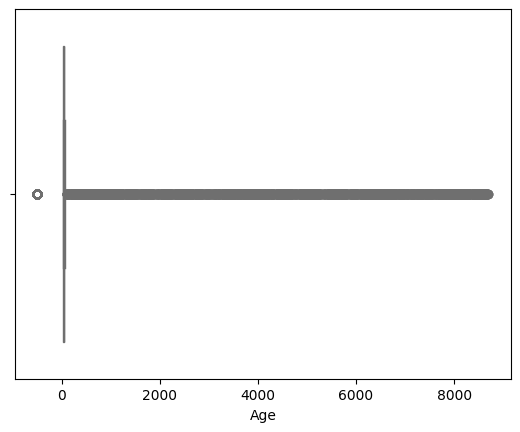

Min: -500
Max: 8698
Q1 (25%): 24.0
Q3 (75%): 42.0
Upper limit: 69.0
Lower limit: -3.0


In [27]:
# Age
sn.boxplot(x=df['Age'], color='skyblue')
plt.show()

print(f"Min:", df['Age'].min())
print(f"Max:", df['Age'].max())
outlier('Age')

# Có khá nhiều Outliners và số âm

<Axes: ylabel='Frequency'>

(5000.0, 850000.0)

Text(0.5, 1.0, 'Annual_Income')

Min: 7005.93
Max: 24198062.0
Number of customer with income higher than 70k: 3969
Q1 (25%): 19457.5
Q3 (75%): 72790.92
Upper limit: 152791.05
Lower limit: -60542.630000000005


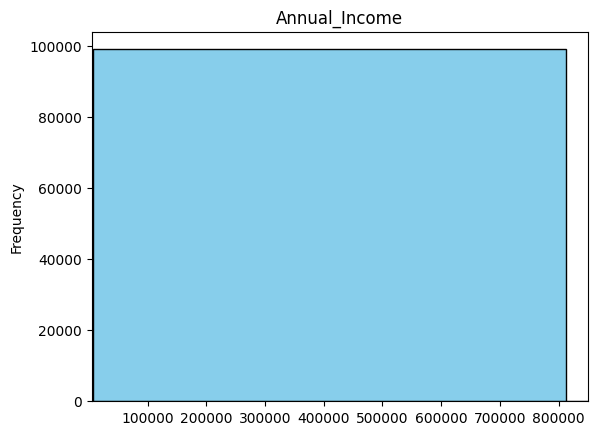

In [28]:
# Annual Income
df['Annual_Income'].plot(kind='hist', bins=30, color='skyblue', edgecolor='black')
plt.xlim(5000, 850000)
plt.title('Annual_Income')

print(f"Min:", df['Annual_Income'].min())
print(f"Max:", df['Annual_Income'].max())

# Count number of customer with income higher than 70k
print(f"Number of customer with income higher than 70k:",
      df.loc[df['Annual_Income'] > 70000, 'Customer_ID'].nunique()
      )
outlier ('Annual_Income')
# Income có thể giao động từ 5k - 800k. Khoảng gần 4k khách hàng có income hơn 70k. 
# Nhưng so với khách hàng còn lại thì vẫn là một con số nhỏ
# Trung bình thu nhập của khách hàng bên Mỹ là 60000k
# Coi nhóm khách hàng trên 200k là outlier

<Axes: ylabel='Frequency'>

Text(0.5, 1.0, 'Monthly_Inhand_Salary')

Min: 303.6454166666666
Max: 15204.633333333331
Q1 (25%): 1625.5682291666667
Q3 (75%): 5957.448333333334
Upper limit: 12455.268489583334
Lower limit: -4872.251927083333


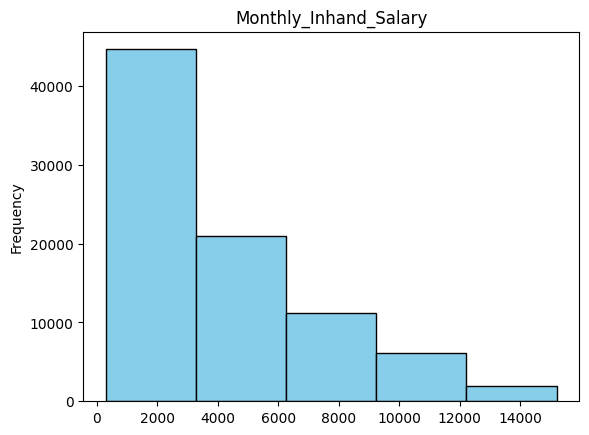

In [29]:
# Monthly_Inhand_Salary
df['Monthly_Inhand_Salary'].plot(kind='hist', bins=5, color='skyblue', edgecolor='black')
plt.title('Monthly_Inhand_Salary')

print(f"Min:", df['Monthly_Inhand_Salary'].min())
print(f"Max:", df['Monthly_Inhand_Salary'].max())
outlier('Monthly_Inhand_Salary')

<Axes: ylabel='Frequency'>

Text(0.5, 1.0, 'Num_Bank_Accounts')

Min: -1
Max: 1798
Q1 (25%): 3.0
Q3 (75%): 7.0
Upper limit: 13.0
Lower limit: -3.0


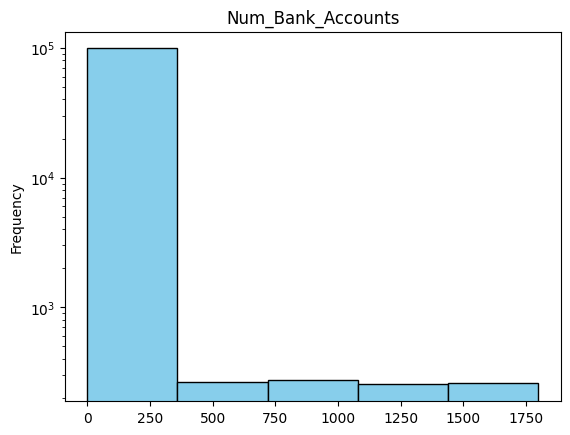

In [30]:
# Num_Bank_Accounts
df['Num_Bank_Accounts'].plot(kind='hist', bins=5, color='skyblue', edgecolor='black')
plt.yscale('log')
plt.title('Num_Bank_Accounts')

print(f"Min:", df['Num_Bank_Accounts'].min()) # Có giá trị âm
print(f"Max:", df['Num_Bank_Accounts'].max())
outlier('Num_Bank_Accounts')

<Axes: xlabel='Num_Bank_Accounts'>

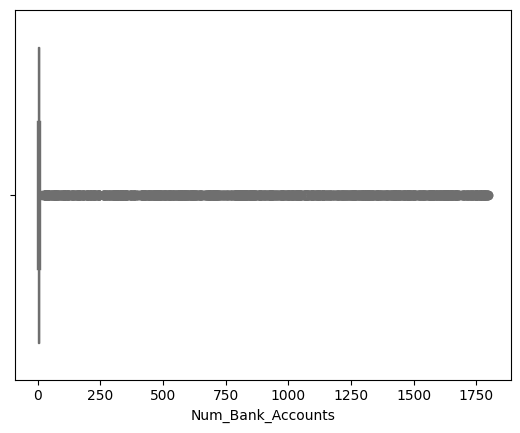

In [31]:
sn.boxplot(x=df['Num_Bank_Accounts'], color='skyblue')
plt.show()

Nhiều outlier khoảng trên 350

<Axes: ylabel='Frequency'>

Text(0.5, 1.0, 'Num_Credit_Card')

Min: 0
Max: 1499
Q1 (25%): 4.0
Q3 (75%): 7.0
Upper limit: 11.5
Lower limit: -0.5


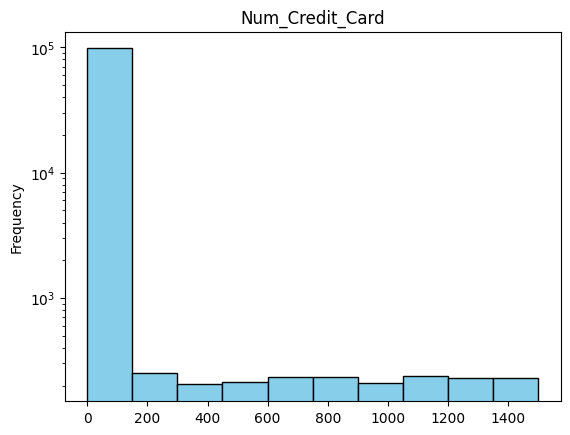

In [32]:
# Num_Credit_Card
df['Num_Credit_Card'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')
plt.yscale('log')
plt.title('Num_Credit_Card')

print(f"Min:", df['Num_Credit_Card'].min())
print(f"Max:", df['Num_Credit_Card'].max())
outlier('Num_Credit_Card')

<Axes: xlabel='Num_Credit_Card'>

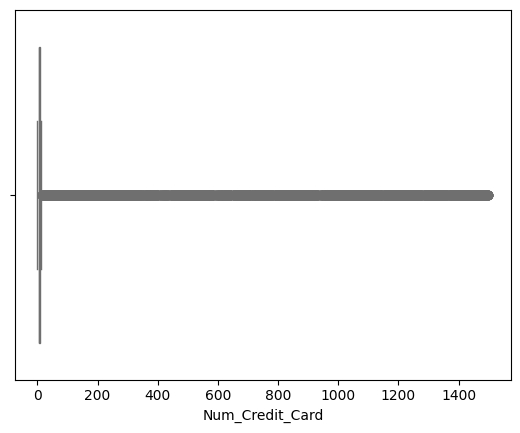

In [33]:
sn.boxplot(x=df['Num_Credit_Card'], color='skyblue')
plt.show()

<Axes: ylabel='Frequency'>

Text(0.5, 1.0, 'Interest_Rate')

Min: 1
Max: 5797
Q1 (25%): 8.0
Q3 (75%): 20.0
Upper limit: 38.0
Lower limit: -10.0


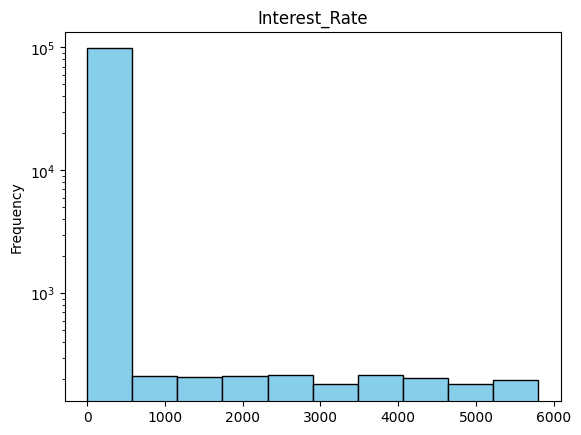

In [34]:
# Interest_Rate
df['Interest_Rate'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')
plt.yscale('log')
plt.title('Interest_Rate')

print(f"Min:", df['Interest_Rate'].min())
print(f"Max:", df['Interest_Rate'].max())
outlier('Interest_Rate')

Tương đương với 2 Features trên, feature này cũng bị rơi vào trường hợp các outlier rải rác ngẫu nhiên trong một khoảng lớn. 

<Axes: ylabel='Frequency'>

Text(0.5, 1.0, 'Num_of_Loan')

Min: -100
Max: 1496
Q1 (25%): 1.0
Q3 (75%): 5.0
Upper limit: 11.0
Lower limit: -5.0


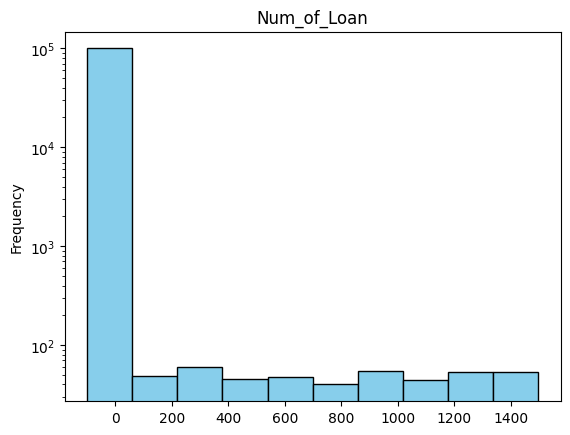

In [35]:
# Num_of_Loan
df['Num_of_Loan'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')
plt.yscale('log')
plt.title('Num_of_Loan')

print(f"Min:", df['Num_of_Loan'].min()) # Có số âm
print(f"Max:", df['Num_of_Loan'].max())
outlier('Num_of_Loan')

Tương tự + Ngoài ra có negative values

<Axes: ylabel='Frequency'>

Text(0.5, 1.0, 'Delay_from_due_date')

Min: -5
Max: 67
Q1 (25%): 10.0
Q3 (75%): 28.0
Upper limit: 55.0
Lower limit: -17.0


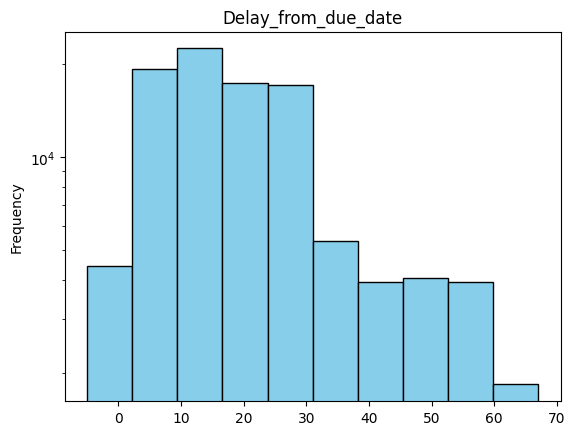

In [36]:
# Delay_from_due_date
df['Delay_from_due_date'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')
plt.yscale('log')
plt.title('Delay_from_due_date')

print(f"Min:", df['Delay_from_due_date'].min()) # có số âm
print(f"Max:", df['Delay_from_due_date'].max())
outlier('Delay_from_due_date')

<Axes: ylabel='Frequency'>

Text(0.5, 1.0, 'Num_of_Delayed_Payment')

Min: -3.0
Max: 4397.0
Q1 (25%): 9.0
Q3 (75%): 18.0
Upper limit: 31.5
Lower limit: -4.5


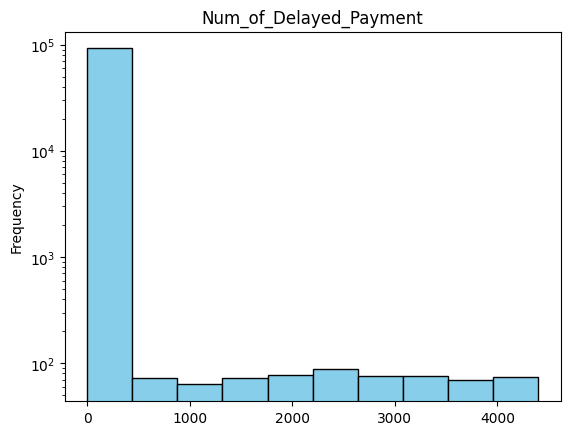

In [37]:
# Num_of_Delayed_Payment
df['Num_of_Delayed_Payment'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')
plt.yscale('log')
plt.title('Num_of_Delayed_Payment')

print(f"Min:", df['Num_of_Delayed_Payment'].min()) # Có số âm
print(f"Max:", df['Num_of_Delayed_Payment'].max())
outlier('Num_of_Delayed_Payment')

<Axes: ylabel='Frequency'>

Text(0.5, 1.0, 'Changed_Credit_Limit')

Min: -6.49
Max: 36.97
Q1 (25%): 5.32
Q3 (75%): 14.87
Upper limit: 29.195
Lower limit: -9.004999999999999


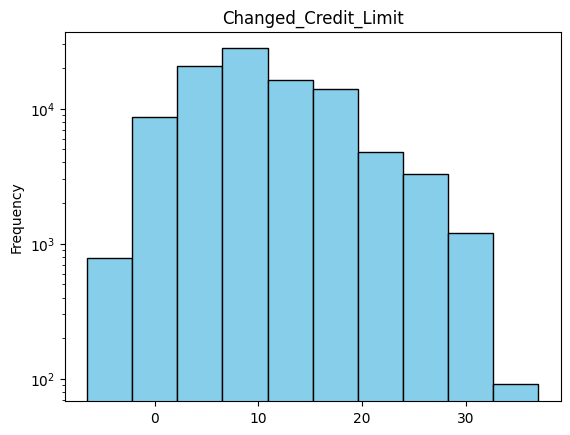

In [38]:
# Changed_Credit_Limit
df['Changed_Credit_Limit'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')
plt.yscale('log')
plt.title('Changed_Credit_Limit')

print(f"Min:", df['Changed_Credit_Limit'].min()) # Có số âm
print(f"Max:", df['Changed_Credit_Limit'].max())
outlier('Changed_Credit_Limit')

<Axes: ylabel='Frequency'>

Text(0.5, 1.0, 'Num_Credit_Inquiries')

Min: 0.0
Max: 2597.0
Q1 (25%): 3.0
Q3 (75%): 9.0
Upper limit: 18.0
Lower limit: -6.0


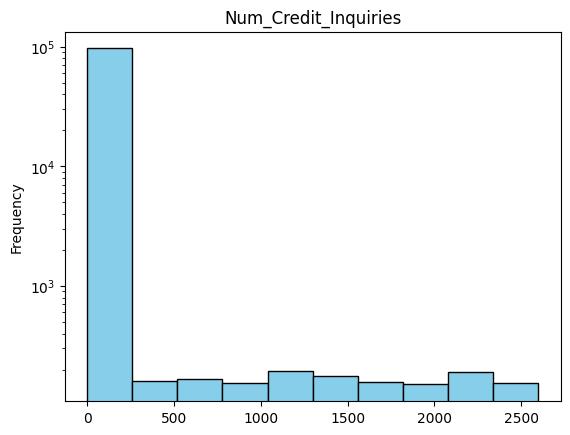

In [39]:
# Num_Credit_Inquiries
df['Num_Credit_Inquiries'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')
plt.yscale('log')
plt.title('Num_Credit_Inquiries')

print(f"Min:", df['Num_Credit_Inquiries'].min()) 
print(f"Max:", df['Num_Credit_Inquiries'].max())
outlier('Num_Credit_Inquiries')

<Axes: ylabel='Frequency'>

Text(0.5, 1.0, 'Outstanding_Debt')

Min: 0.23
Max: 4998.07
Q1 (25%): 566.0725
Q3 (75%): 1945.9625
Upper limit: 4015.7975
Lower limit: -1503.7625


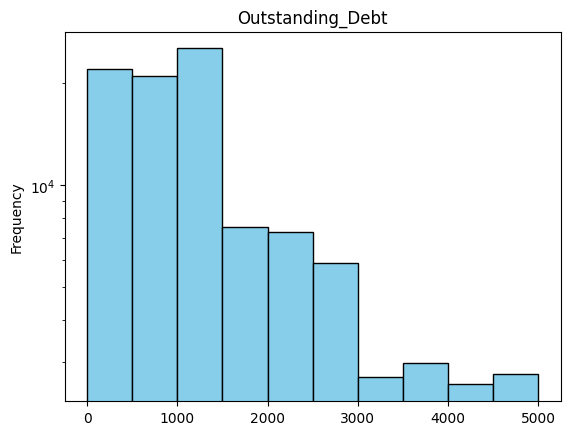

In [40]:
# Outstanding_Debt
df['Outstanding_Debt'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')
plt.yscale('log')
plt.title('Outstanding_Debt')

print(f"Min:", df['Outstanding_Debt'].min()) 
print(f"Max:", df['Outstanding_Debt'].max())
outlier('Outstanding_Debt')

<Axes: ylabel='Frequency'>

Text(0.5, 1.0, 'Credit_Utilization_Ratio')

Min: 20.0
Max: 50.00000000000001
Q1 (25%): 28.05256656125577
Q3 (75%): 36.4966630559621
Upper limit: 49.1628077980216
Lower limit: 15.38642181919627


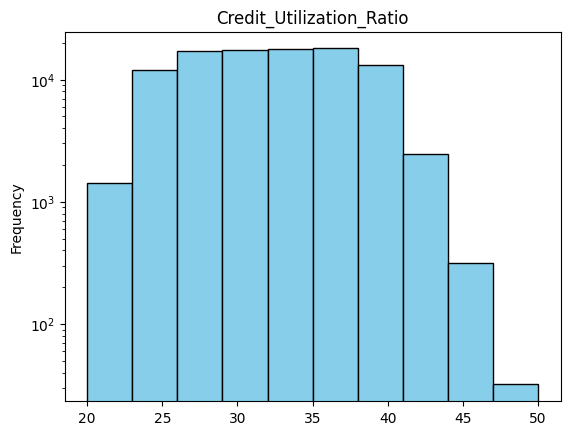

In [41]:
# Credit_Utilization_Ratio
df['Credit_Utilization_Ratio'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')
plt.yscale('log')
plt.title('Credit_Utilization_Ratio')

print(f"Min:", df['Credit_Utilization_Ratio'].min()) 
print(f"Max:", df['Credit_Utilization_Ratio'].max())
outlier('Credit_Utilization_Ratio')

<Axes: ylabel='Frequency'>

Text(0.5, 1.0, 'Total_EMI_per_month')

Min: 0.0
Max: 82331.0
Q1 (25%): 30.306660494686994
Q3 (75%): 161.22424910969863
Upper limit: 357.60063203221614
Lower limit: -166.06972242783047


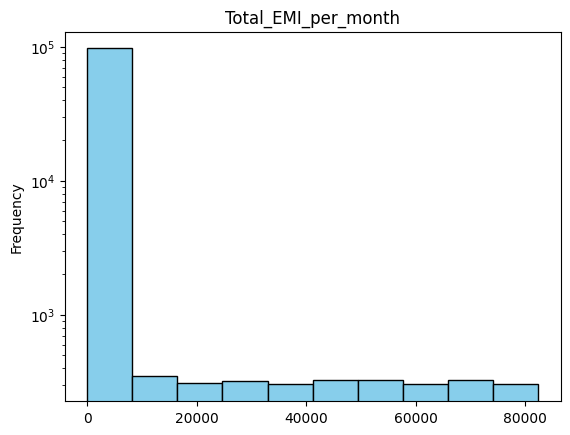

In [42]:
# Total_EMI_per_month
df['Total_EMI_per_month'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')
plt.yscale('log')
plt.title('Total_EMI_per_month')

print(f"Min:", df['Total_EMI_per_month'].min()) 
print(f"Max:", df['Total_EMI_per_month'].max())
outlier('Total_EMI_per_month')

<Axes: ylabel='Frequency'>

Text(0.5, 1.0, 'Amount_invested_monthly')

Min: 0.0
Max: 1977.326102249349
Q1 (25%): 72.23669248737778
Q3 (75%): 236.81581421526977
Upper limit: 483.68449680710773
Lower limit: -174.6319901044602


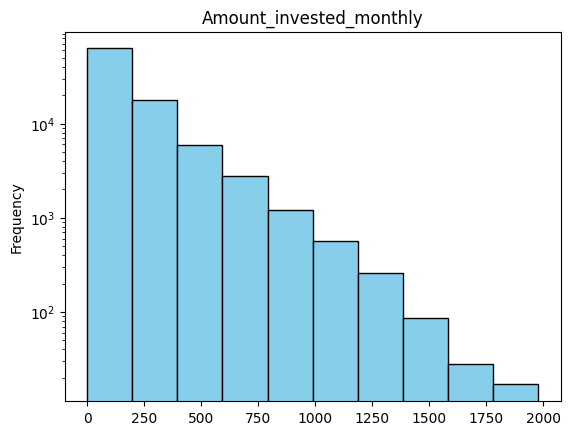

In [43]:
# Amount_invested_monthly
df['Amount_invested_monthly'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')
plt.yscale('log')
plt.title('Amount_invested_monthly')

print(f"Min:", df['Amount_invested_monthly'].min()) 
print(f"Max:", df['Amount_invested_monthly'].max())
outlier('Amount_invested_monthly')

<Axes: ylabel='Frequency'>

Text(0.5, 1.0, 'Monthly_Balance')

Min: 0.0077596647753352
Max: 1602.0405189622518
Q1 (25%): 270.1066299013477
Q3 (75%): 470.26293845209784
Upper limit: 770.4974012782232
Lower limit: -30.12783292477758


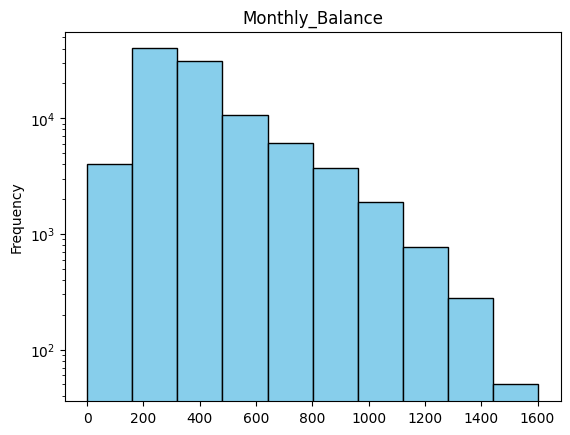

In [44]:
# Monthly_Balance
df['Monthly_Balance'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')
plt.yscale('log')
plt.title('Monthly_Balance')

print(f"Min:", df['Monthly_Balance'].min()) 
print(f"Max:", df['Monthly_Balance'].max())
outlier('Monthly_Balance')

### Nhóm Categorical

<Axes: xlabel='Month'>

Text(0.5, 1.0, 'Count of Months')

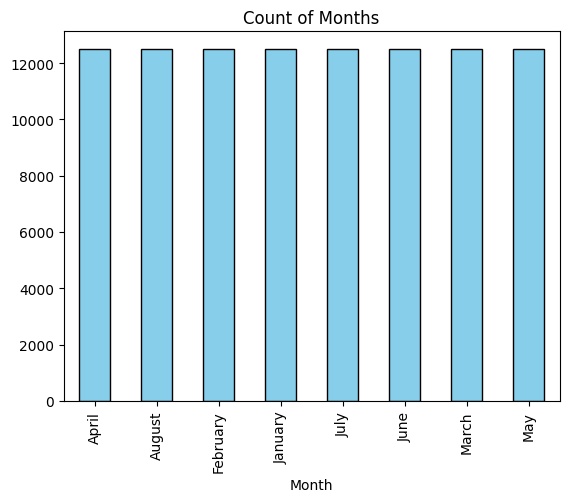

In [45]:
# Month
df['Month'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Count of Months')

<Axes: xlabel='Occupation'>

Text(0.5, 1.0, 'Count of Occupation')

0

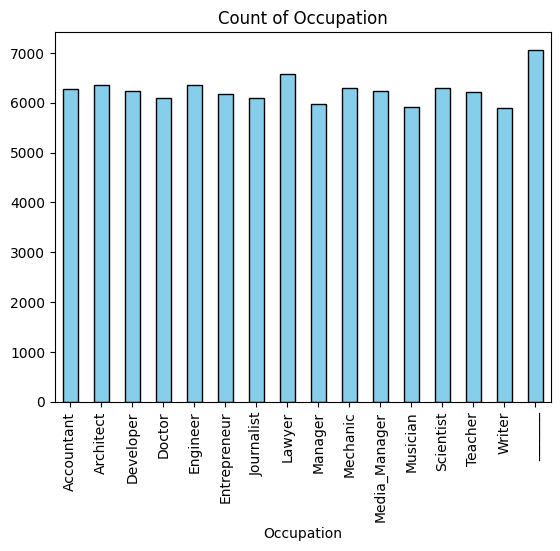

In [46]:
# Occupation
df['Occupation'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Count of Occupation')
# There is value "____"

df["Occupation"].isnull().sum()

Số lượng outlier của feature có tận 7k, nhiều nhất so với các class còn lại

In [47]:
# Type_of_Loan - Sau khi encoding sẽ vẽ hình
df["Type_of_Loan"].value_counts()

Type_of_Loan
Not Specified                                                                                                                         1408
Credit-Builder Loan                                                                                                                   1280
Personal Loan                                                                                                                         1272
Debt Consolidation Loan                                                                                                               1264
Student Loan                                                                                                                          1240
                                                                                                                                      ... 
Not Specified, Mortgage Loan, Auto Loan, and Payday Loan                                                                                 8
Payday Loan, M

<Axes: xlabel='Credit_Mix'>

Text(0.5, 1.0, 'Credit Mix')

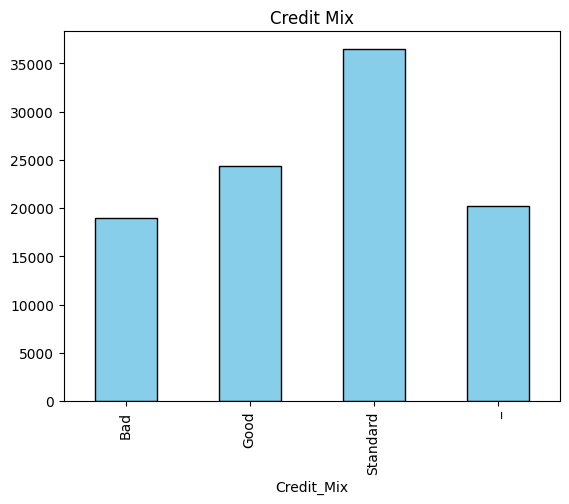

In [48]:
# Credit_Mix
df['Credit_Mix'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Credit Mix')
# There is value "____"

Khoảng 20k outliers

In [49]:
# Credit_History_Age - Encoding thành months

<Axes: xlabel='Payment_of_Min_Amount'>

Text(0.5, 1.0, 'Payment_of_Min_Amount')

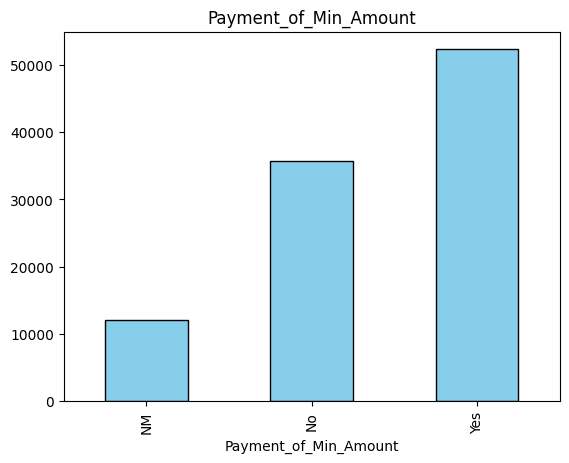

In [50]:
# Payment_of_Min_Amount
df['Payment_of_Min_Amount'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Payment_of_Min_Amount')

<Axes: xlabel='Payment_Behaviour'>

Text(0.5, 1.0, 'Payment_Behaviour')

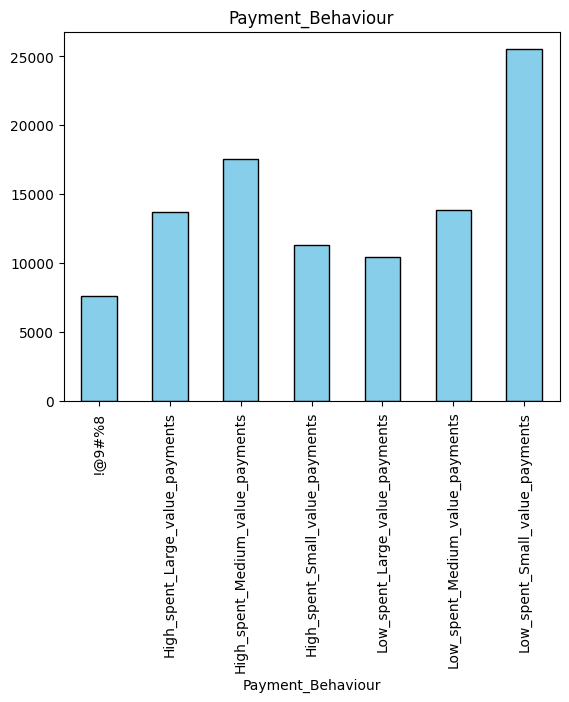

In [51]:
# Payment_Behaviour
df['Payment_Behaviour'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Payment_Behaviour')
# There are outliners

Khoảng 7k outliers

<Axes: xlabel='Credit_Score'>

Text(0.5, 1.0, 'Credit_Score')

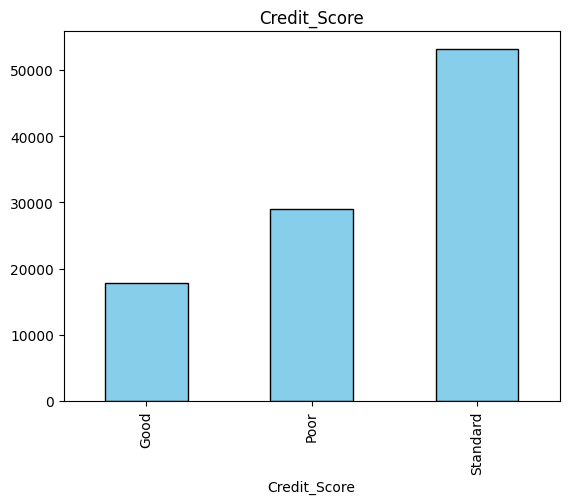

In [52]:
# Credit_Score - Target
df['Credit_Score'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Credit_Score')
# Imbalanced

# Kết luận

### Nhận xét
- ID not useful vì chỉ là STT các giao dịch
- Name has missing values but not useful
- SSN has outliners but not useful



- Credit_Score inbalanced, categorize it into binary instead of 3
- Should put Type_of_Loan to endcoding
- Credit_History_Age change date format (to months?)
- Viết function xử lý từng nhóm data
- Tách train với test set, phân theo Customer_ID
- Use Distribution to detect outliner (IQR)
- Month encode thành dạng số
- Cần phân loại 2 nhóm numerical - Discrete & Continuous
- Luật outlier của các nhóm -> Xây function cho từng nhóm


List các feature có outlier
- Age
- Annual Income?
- Num_Bank_Accounts
- Num_Credit_Card
- Interest_Rate
- Num_of_Loan
- Num_of_Delayed_Payment
- Num_Credit_Inquiries
- Total_EMI_per_month
- Occupation
- Credit_Mix
- Payment_Behaviour

List các feature có số âm
- Age
- Num_Bank_Accounts
- Num_of_Loan
- Delay_from_due_date
- Num_of_Delayed_Payment
- Changed_Credit_Limit?

List các feature có missing values
- Num_of_Delayed_Payment
- Changed_Credit_Limit?
- Amount_invested_monthly          
- Monthly_Balance
- Monthly_Inhand_Salary

- Liệt kê vấn đè -> phương pháp và kết quả thu được -> visualization sau khi cleaning 

List các feature ko có outlier:
- Monthly_Inhand_Salary (missing values)
- Delay_from_due_date (just negative number)
- Changed_Credit_Limit (just negative number)
- OUtstanding_Debt
- Credit_Utilization_Ratio
- Amount_ivestd_monthly
- Monthly_Balance

3 functions for 3 groups of dataset
- Group 1 (Categories): usual cases such ____, _ or @#$$#$ in texts among with missing values
- Group 2 (Numericals): usual cases such negative numbers and missing values
- Group 3 (Numericals but wrong dtype): wrong data type due to symbols, and missing values
- Group 4 (Date): available function to deal with
 